# TDA 상태 구분력 검증 — 30Hz 저주파 전력 신호

> **목적**: 30Hz P(t) 신호에서 TDA(Persistence Image)가 전력 수준(W) 이외의 **파형 위상 구조**로 상태를 구분하는지 확인  
> 전체 파이프라인 실행 전에 핵심 전제를 검증한다.

**검증 가전 (상태 차이가 명확한 3종)**
- **온수매트**: 써모스탯 사이클 주기 차이 (저출력 ↔ 고출력)
- **세탁기**: 모터 패턴 구조 차이 (교반 ↔ 탈수)
- **에어컨**: 압축기 유무 (팬 ↔ 냉방)

**검증 설계**
- GT 레이블 없음 — W-range로 상태를 미리 정의하지 않는다
- ON 구간 윈도우 수집 → PI 계산 → K-Means 클러스터링 → 클러스터 품질 측정
- **글로벌 정규화 PI**: PC1이 mean_w와 상관되는지 확인 (진폭 정보 보존 sanity check)
- **per-segment 정규화 PI**: W 정보 제거 후 silhouette score → 순수 위상 구조 구분력 측정
- per-segment silhouette ≥ 0.3 이면 TDA가 파형 구조 차이를 실제로 포착하고 있다고 판단

In [1]:
!pip install -q gcsfs pyarrow gudhi ripser scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.4 MB/s eta 0:00:00


In [2]:
from google.colab import auth, drive
auth.authenticate_user()
drive.mount('/content/drive')
print('인증 완료')

Mounted at /content/drive
인증 완료


In [3]:
import glob
import io
import subprocess
import warnings
from concurrent.futures import ThreadPoolExecutor

import gcsfs
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import ripser as ripser_lib
from gudhi.representations import PersistenceImage
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
ttf = glob.glob('/usr/share/fonts/**/*Nanum*Gothic*.ttf', recursive=True)
if ttf:
    fm.fontManager.addfont(ttf[0])
    prop = fm.FontProperties(fname=ttf[0])
    plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
print('임포트 완료')

임포트 완료


In [4]:
BUCKET_PREFIX = 'ax-nilm-data-dhwang0803-us/nilm/training_dev10'
LABEL_PATH    = 'ax-nilm-data-dhwang0803-us/nilm/labels/training.parquet'

# TDA 파라미터 — mode_detector.py와 동일
EMBED_DIM    = 3
EMBED_LAG    = 10
MIN_POINTS   = 50
IMG_SIZE     = 20
MAX_EDGE_LEN = 0.5
PI_BANDWIDTH = 0.05
WINDOW_SIZE  = 512

N_WINDOWS = 200  # 가전당 수집할 총 윈도우 수 (K=4 의류건조기 고려)

ALL_HOUSES = [
    'house_011', 'house_015', 'house_016', 'house_033',
    'house_039', 'house_049', 'house_054', 'house_063', 'house_067',
]  # house_017 GCS hang 제외
AC_HOUSES = ['house_015', 'house_054', 'house_063']

# 검증 대상 10종 — build_tda_references.ipynb와 동일 파라미터
TARGETS = {
    '에어컨':            {'label_key': '에어컨',       'max_w': 50.0,   'K': 3, 'houses': AC_HOUSES},
    '김치냉장고':        {'label_key': '김치 냉장고',   'max_w': 200.0,  'K': 3, 'houses': ALL_HOUSES},
    '제습기':            {'label_key': '제습기',        'max_w': 500.0,  'K': 3, 'houses': ALL_HOUSES},
    '세탁기':            {'label_key': '세탁기',        'max_w': 700.0,  'K': 2, 'houses': ALL_HOUSES},
    '의류건조기':        {'label_key': '의류건조기',    'max_w': 2000.0, 'K': 4, 'houses': ALL_HOUSES},
    '일반 냉장고':       {'label_key': '일반 냉장고',   'max_w': 400.0,  'K': 3, 'houses': ALL_HOUSES},
    '식기세척기/건조기': {'label_key': '식기세척기',    'max_w': 2000.0, 'K': 3, 'houses': ALL_HOUSES},
    '온수매트':          {'label_key': '온수매트',      'max_w': 500.0,  'K': 3, 'houses': ALL_HOUSES},
    '전기밥솥':          {'label_key': '전기밥솥',      'max_w': 1500.0, 'K': 2, 'houses': ALL_HOUSES},
    '전기장판/담요':     {'label_key': '전기장판',      'max_w': 200.0,  'K': 2, 'houses': ALL_HOUSES},
}

print(f'검증 대상 {len(TARGETS)}종')

설정 완료


In [5]:
gcs = gcsfs.GCSFileSystem()
labels_df = pq.read_table(
    LABEL_PATH,
    filesystem=pa.fs.PyFileSystem(pa.fs.FSSpecHandler(gcs))
).to_pandas()
print(f'라벨 로드: {len(labels_df)}행')


def get_on_periods(house_id, channel):
    rows = labels_df[
        (labels_df['household_id'] == house_id) &
        (labels_df['channel'] == channel)
    ]
    periods = []
    for _, row in rows.iterrows():
        s = pd.to_datetime(row.get('start_ts'))
        e = pd.to_datetime(row.get('end_ts'))
        if pd.notna(s) and pd.notna(e):
            s = s.tz_convert('UTC').tz_localize(None) if s.tzinfo else s
            e = e.tz_convert('UTC').tz_localize(None) if e.tzinfo else e
            periods.append((s, e))
    return periods


def load_raw_channel(house_id, channel):
    periods = get_on_periods(house_id, channel)
    if not periods:
        return pd.DataFrame(columns=['date_time', 'active_power'])

    on_dates = set()
    for s, e in periods:
        d = s.date()
        while d <= e.date():
            on_dates.add(d.strftime('%Y%m%d'))
            d += pd.Timedelta(days=1)

    path = f'{BUCKET_PREFIX}/household_id={house_id}/channel={channel}'
    files = []
    for date in sorted(on_dates):
        try:
            files.extend(gcs.ls(f'{path}/date={date}'))
        except Exception:
            pass
    if not files:
        return pd.DataFrame(columns=['date_time', 'active_power'])

    def _read(f):
        with gcs.open(f, 'rb') as fp:
            buf = fp.read()
        return pq.read_table(io.BytesIO(buf), columns=['date_time', 'active_power']).to_pandas()

    with ThreadPoolExecutor(max_workers=8) as pool:
        dfs = list(pool.map(_read, files))

    df = pd.concat(dfs, ignore_index=True)
    df['date_time'] = pd.to_datetime(df['date_time']).dt.tz_localize(None)
    return df.sort_values('date_time').reset_index(drop=True)


print('로드 함수 정의 완료')

라벨 로드: 465001행
로드 함수 정의 완료


In [6]:
_PI = PersistenceImage(
    bandwidth=PI_BANDWIDTH,
    resolution=[IMG_SIZE, IMG_SIZE],
    im_range=[0, 1, 0, 1],
)


def time_delay_embed(signal):
    n = len(signal) - (EMBED_DIM - 1) * EMBED_LAG
    if n <= 0:
        return np.empty((0, EMBED_DIM))
    return np.stack(
        [signal[i: i + n] for i in range(0, EMBED_DIM * EMBED_LAG, EMBED_LAG)],
        axis=1,
    )


def _pi_from_norm(norm):
    if norm.max() < 1e-6:
        return None
    cloud = time_delay_embed(norm)
    if len(cloud) < MIN_POINTS:
        return None
    dgms = ripser_lib.ripser(cloud, maxdim=1, thresh=MAX_EDGE_LEN)['dgms'][1]
    if len(dgms) == 0:
        return np.zeros(IMG_SIZE * IMG_SIZE, dtype=np.float32)
    dgms_finite = dgms[dgms[:, 1] != np.inf]
    if len(dgms_finite) == 0:
        return np.zeros(IMG_SIZE * IMG_SIZE, dtype=np.float32)
    return _PI.fit_transform([dgms_finite])[0].flatten().astype(np.float32)


def compute_pi_global(window, max_w):
    """글로벌 정규화: signal / max_w — 진폭 정보 보존."""
    norm = np.clip(window / max_w, 0.0, 1.0).astype(np.float32)
    return _pi_from_norm(norm)


def compute_pi_perseg(window):
    """Per-segment 정규화: (x-min)/(max-min) — 진폭 정보 제거, 위상 구조만 남음."""
    s_min, s_max = float(window.min()), float(window.max())
    if s_max - s_min < 1e-6:
        return None
    norm = ((window - s_min) / (s_max - s_min)).astype(np.float32)
    return _pi_from_norm(norm)


print('TDA 함수 정의 완료')

TDA 함수 정의 완료


## 1단계: ON 구간 윈도우 수집

W-range 상태 레이블 없이 ON 구간 전체에서 슬라이딩 윈도우를 수집한다.  
mean_w는 시각화용으로만 기록.

In [7]:
# {app_name: {'windows': [...], 'mean_ws': [...]}}
collected = {}

for app_name, cfg in TARGETS.items():
    max_w = cfg['max_w']
    print(f'\n[{app_name}] 수집 시작')

    windows, mean_ws = [], []

    rows = labels_df[
        labels_df['appliance_name'].str.contains(cfg['label_key'], na=False) &
        labels_df['household_id'].isin(cfg['houses'])
    ][['household_id', 'channel']].drop_duplicates()
    channels = list(rows.itertuples(index=False, name=None))
    print(f'  채널 {len(channels)}개')

    for house_id, channel in channels:
        if len(windows) >= N_WINDOWS:
            break

        raw = load_raw_channel(house_id, channel)
        periods = get_on_periods(house_id, channel)
        if raw.empty or not periods:
            continue

        raw_idx = raw.set_index('date_time').sort_index()

        for s, e in periods:
            seg = raw_idx.loc[s:e, 'active_power'].values.astype(np.float32)
            if len(seg) < WINDOW_SIZE:
                continue
            for start in range(0, len(seg) - WINDOW_SIZE + 1, WINDOW_SIZE):
                if len(windows) >= N_WINDOWS:
                    break
                w = seg[start: start + WINDOW_SIZE]
                windows.append(w)
                mean_ws.append(float(w.mean()))
            if len(windows) >= N_WINDOWS:
                break

    print(f'  수집된 윈도우: {len(windows)}개, mean_w 범위: {min(mean_ws):.1f}~{max(mean_ws):.1f}W')
    collected[app_name] = {
        'windows': windows,
        'mean_ws': np.array(mean_ws),
        'max_w': max_w,
        'K': cfg['K'],
    }

print('\n수집 완료')


[온수매트] 수집 시작
  채널 2개
  수집된 윈도우: 120개, mean_w 범위: 139.6~189.3W

[세탁기] 수집 시작
  채널 4개
  수집된 윈도우: 120개, mean_w 범위: 6.5~89.2W

[에어컨] 수집 시작
  채널 3개
  수집된 윈도우: 120개, mean_w 범위: 20.9~29.1W

수집 완료


## 2단계: PI 계산

글로벌 정규화 / per-segment 정규화 동시 계산.

In [8]:
results = {}

for app_name, data in collected.items():
    max_w = data['max_w']
    print(f'\n[{app_name}] PI 계산 중...')

    pis_global, pis_perseg, valid_mean_ws = [], [], []

    for window, mean_w in zip(data['windows'], data['mean_ws']):
        pi_g = compute_pi_global(window, max_w)
        pi_p = compute_pi_perseg(window)
        if pi_g is not None and pi_p is not None:
            pis_global.append(pi_g)
            pis_perseg.append(pi_p)
            valid_mean_ws.append(mean_w)

    results[app_name] = {
        'global':    np.stack(pis_global),
        'perseg':    np.stack(pis_perseg),
        'mean_ws':   np.array(valid_mean_ws),
        'K':         data['K'],
    }
    print(f'  완료: {len(valid_mean_ws)}개 샘플')

print('\nPI 계산 완료')


[온수매트] PI 계산 중...
  완료: 120개 샘플

[세탁기] PI 계산 중...
  완료: 120개 샘플

[에어컨] PI 계산 중...
  완료: 120개 샘플

PI 계산 완료


## 3단계: PCA scatter

**왼쪽 (글로벌 정규화)**: mean_w로 컬러링 — PC1이 W와 상관되면 진폭 정보가 PI에 보존된 것 (sanity check)  
**오른쪽 (per-segment 정규화)**: K-Means 클러스터로 컬러링 — W 정보 없이도 자연스러운 군집이 형성되면 위상 구조 구분력 있음

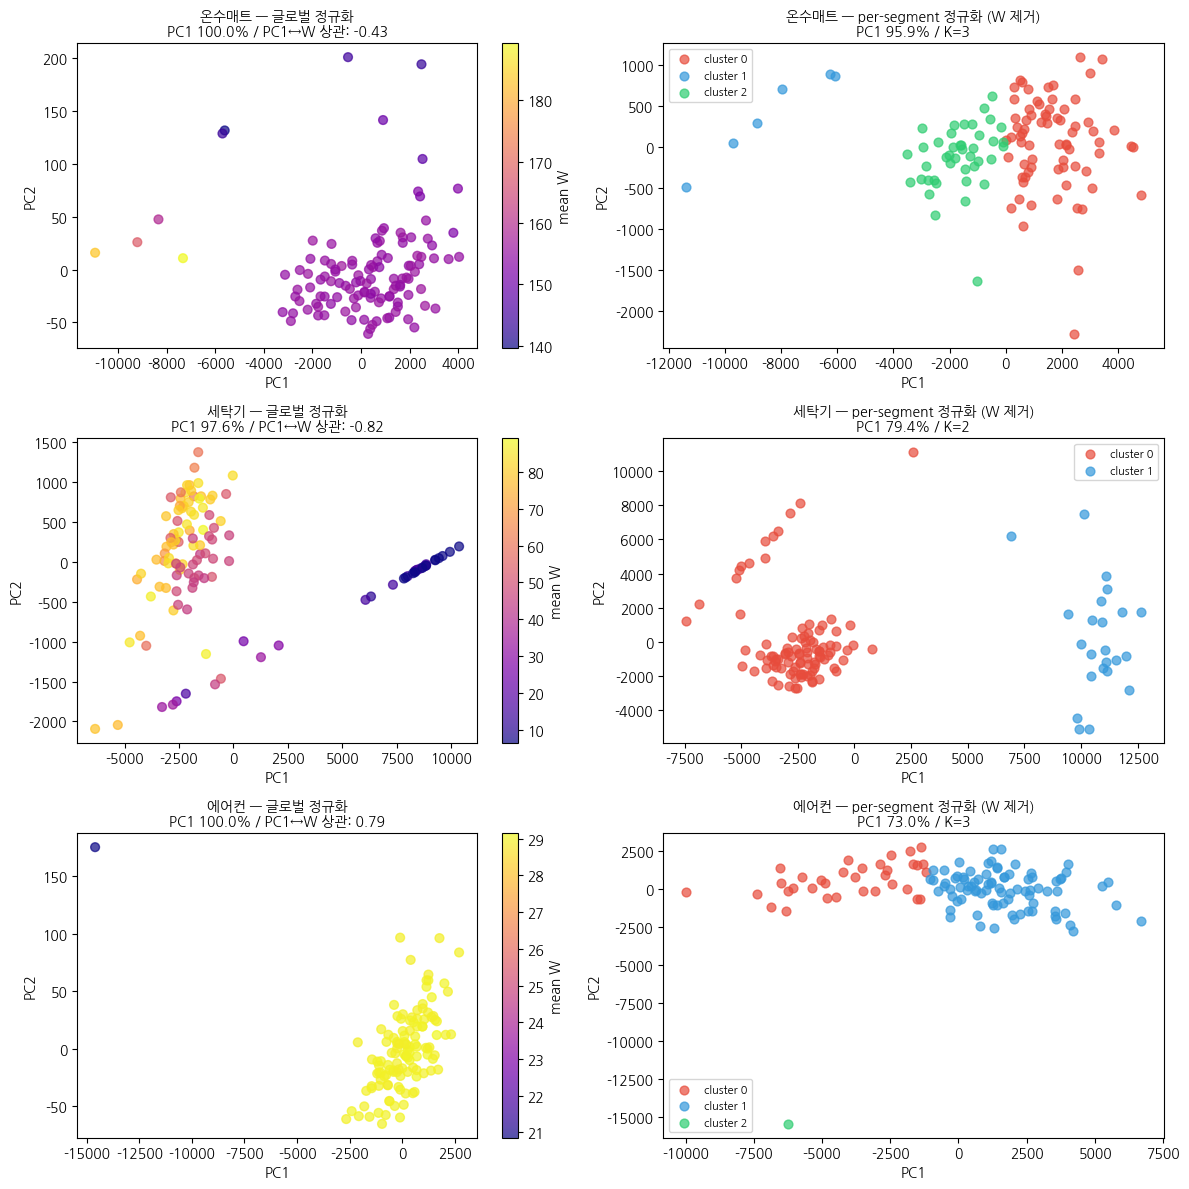

→ 왼쪽 PC1↔W 상관 ≥ 0.8: 진폭 정보 보존 확인
→ 오른쪽 군집이 분리되면: W 없이도 위상 구조로 구분됨


In [9]:
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

km_labels = {}  # 나중에 히트맵에서 재사용

fig, axes = plt.subplots(len(results), 2, figsize=(12, len(results) * 4))
if len(results) == 1:
    axes = axes[np.newaxis, :]

for row_i, (app_name, data) in enumerate(results.items()):
    K = data['K']
    mean_ws = data['mean_ws']

    # 왼쪽: 글로벌 — mean_w 컬러맵
    ax = axes[row_i][0]
    pca = PCA(n_components=2, random_state=42)
    X2d = pca.fit_transform(data['global'])
    var = pca.explained_variance_ratio_
    corr = float(np.corrcoef(X2d[:, 0], mean_ws)[0, 1])
    sc = ax.scatter(X2d[:, 0], X2d[:, 1], c=mean_ws, cmap='plasma', alpha=0.7, s=40)
    plt.colorbar(sc, ax=ax, label='mean W')
    ax.set_title(
        f'{app_name} — 글로벌 정규화\nPC1 {var[0]:.1%} / PC1↔W 상관: {corr:.2f}',
        fontsize=10
    )
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

    # 오른쪽: per-segment — K-Means 클러스터 컬러
    ax = axes[row_i][1]
    km = KMeans(n_clusters=K, random_state=42, n_init=20)
    labels = km.fit_predict(data['perseg'])
    km_labels[app_name] = labels

    pca2 = PCA(n_components=2, random_state=42)
    X2d2 = pca2.fit_transform(data['perseg'])
    var2 = pca2.explained_variance_ratio_
    for k in range(K):
        mask = labels == k
        ax.scatter(X2d2[mask, 0], X2d2[mask, 1],
                   c=COLORS[k], label=f'cluster {k}', alpha=0.7, s=40)
    ax.set_title(
        f'{app_name} — per-segment 정규화 (W 제거)\nPC1 {var2[0]:.1%} / K={K}',
        fontsize=10
    )
    ax.legend(fontsize=8)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()
print('→ 왼쪽 PC1↔W 상관 ≥ 0.8: 진폭 정보 보존 확인')
print('→ 오른쪽 군집이 분리되면: W 없이도 위상 구조로 구분됨')

## 4단계: 클러스터별 평균 PI 히트맵

per-segment K-Means 클러스터 중심 PI — 클러스터 간 패턴이 다르면 TDA가 구조를 포착한 것.

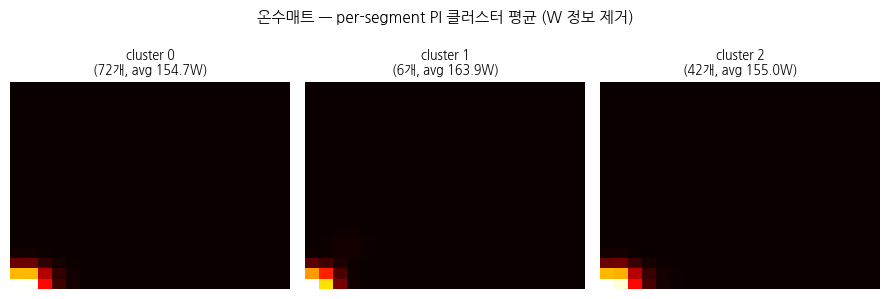

→ 클러스터 간 히트맵 패턴이 다르면 TDA가 파형 구조를 포착하고 있음


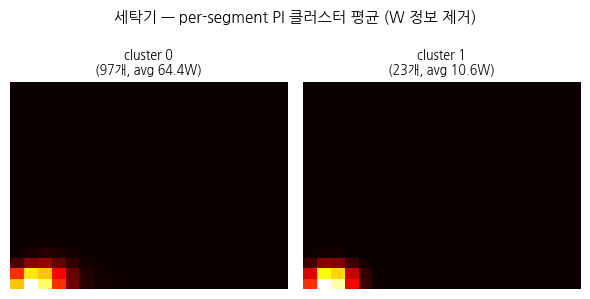

→ 클러스터 간 히트맵 패턴이 다르면 TDA가 파형 구조를 포착하고 있음


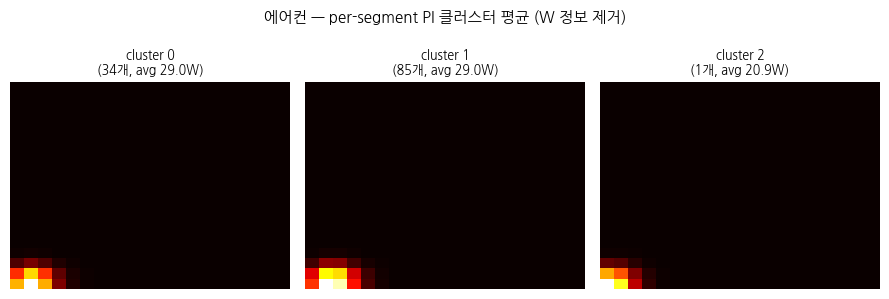

→ 클러스터 간 히트맵 패턴이 다르면 TDA가 파형 구조를 포착하고 있음


In [10]:
for app_name, data in results.items():
    K = data['K']
    labels = km_labels[app_name]
    mean_ws = data['mean_ws']

    fig, axes = plt.subplots(1, K, figsize=(K * 3, 3))
    if K == 1:
        axes = [axes]
    fig.suptitle(f'{app_name} — per-segment PI 클러스터 평균 (W 정보 제거)', fontsize=11)

    for k in range(K):
        mask = labels == k
        avg_pi = data['perseg'][mask].mean(axis=0).reshape(IMG_SIZE, IMG_SIZE)
        avg_w = float(mean_ws[mask].mean())
        axes[k].imshow(avg_pi, origin='lower', cmap='hot', aspect='auto')
        axes[k].set_title(f'cluster {k}\n({mask.sum()}개, avg {avg_w:.1f}W)', fontsize=9)
        axes[k].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'→ 클러스터 간 히트맵 패턴이 다르면 TDA가 파형 구조를 포착하고 있음')

## 5단계: Silhouette Score — 위상 구조 구분력 정량 측정

Silhouette: 1.0 = 완벽한 클러스터 분리, 0.0 = 경계 애매, 음수 = 잘못된 클러스터  
**per-segment silhouette ≥ 0.3** → TDA가 W 없이도 파형 구조로 상태를 구분함  
글로벌 vs per-segment 비교: per-segment가 낮으면 구분력이 W 정보에 의존하는 것

In [11]:
print(f'{"가전":<16} {"정규화":<14} {"K":<4} {"Silhouette":<12} 판정')
print('-' * 62)

for app_name, data in results.items():
    K = data['K']

    # 글로벌: K-Means 새로 fit
    km_g = KMeans(n_clusters=K, random_state=42, n_init=20)
    pred_g = km_g.fit_predict(data['global'])
    sil_g = silhouette_score(data['global'], pred_g)

    # per-segment: 3단계에서 fit한 labels 재사용
    sil_p = silhouette_score(data['perseg'], km_labels[app_name])

    for sil, label in [(sil_g, '글로벌'), (sil_p, 'per-segment')]:
        verdict = '✅ 위상 구분력 있음' if sil >= 0.3 else ('△ 약함' if sil >= 0.1 else '❌ 없음')
        print(f'{app_name:<16} {label:<14} {K:<4} {sil:<12.3f} {verdict}')

print()
print('※ per-segment ≥ 0.3: W 정보 없이도 TDA가 파형 구조를 구분 → 파이프라인 유효')
print('※ per-segment << 글로벌: 구분력이 W 차이에만 의존 → TDA 파라미터 재검토 필요')

가전           정규화            K    Silhouette   판정
--------------------------------------------------------
온수매트         글로벌            3    0.587        ✅ 위상 구분력 있음
온수매트         per-segment    3    0.540        ✅ 위상 구분력 있음
세탁기          글로벌            2    0.846        ✅ 위상 구분력 있음
세탁기          per-segment    2    0.750        ✅ 위상 구분력 있음
에어컨          글로벌            3    0.541        ✅ 위상 구분력 있음
에어컨          per-segment    3    0.504        ✅ 위상 구분력 있음

※ per-segment ≥ 0.3: W 정보 없이도 TDA가 파형 구조를 구분 → 파이프라인 유효
※ per-segment << 글로벌: 구분력이 W 차이에만 의존 → TDA 파라미터 재검토 필요


## 6단계: W-range vs TDA Silhouette 비교

동일한 K로 **mean_w 1D K-Means** vs **PI 400D K-Means** silhouette을 비교한다.  
- `sil_W ≈ 0` + `sil_TDA ≥ 0.3` → 전력량으로 분리 불가한 구조를 TDA가 포착  
- `sil_W` 높고 `sil_TDA` 낮음 → W-range 분류로 충분, TDA 불필요  


In [ ]:
# W-range K-Means vs TDA K-Means silhouette 비교

print(f'{"가전":<16} {"K":<4} {"sil_W":>8} {"sil_TDA(per-seg)":>18} {"차이":>8}  판정')
print('=' * 72)

comparison = []
for app_name, data in results.items():
    K = data['K']
    mean_ws = np.array(collected[app_name]['mean_ws']).reshape(-1, 1)

    km_w = KMeans(n_clusters=K, random_state=42, n_init=20)
    pred_w = km_w.fit_predict(mean_ws)
    try:
        sil_w = silhouette_score(mean_ws, pred_w)
    except Exception:
        sil_w = 0.0

    sil_tda = silhouette_score(data['perseg'], km_labels[app_name])
    diff = sil_tda - sil_w

    if diff > 0.1:
        verdict = '✅ TDA 유효'
    elif diff > -0.1:
        verdict = '➖ 비슷'
    else:
        verdict = '⚠️  W 우세'

    comparison.append({'app': app_name, 'K': K, 'sil_w': sil_w, 'sil_tda': sil_tda, 'diff': diff})
    print(f'{app_name:<16} {K:<4} {sil_w:>8.3f} {sil_tda:>18.3f} {diff:>+8.3f}  {verdict}')

print()
tda_wins = sum(1 for c in comparison if c['diff'] >  0.1)
ties     = sum(1 for c in comparison if abs(c['diff']) <= 0.1)
w_wins   = sum(1 for c in comparison if c['diff'] < -0.1)
print(f'TDA 우위: {tda_wins}종 | 비슷: {ties}종 | W 우세: {w_wins}종')

# 시각화
apps  = [c['app']     for c in comparison]
sw    = [c['sil_w']   for c in comparison]
st    = [c['sil_tda'] for c in comparison]
x = np.arange(len(apps))
w = 0.35

fig, ax = plt.subplots(figsize=(max(10, len(apps)), 5))
ax.bar(x - w/2, sw, w, label='W-range K-Means', color='#95a5a6', alpha=0.85)
ax.bar(x + w/2, st, w, label='TDA K-Means (per-seg)', color='#3498db', alpha=0.85)
ax.axhline(0.3, color='red', linestyle='--', linewidth=1, label='유효 기준 (0.3)')
ax.set_xticks(x)
ax.set_xticklabels(apps, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Silhouette Score')
ax.set_title('W-range vs TDA — 클러스터 응집력 비교')
ax.legend()
ax.set_ylim(-0.1, 1.0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ax_nilm_cold_start/wrange_vs_tda_silhouette.png',
            dpi=120, bbox_inches='tight')
plt.show()
print('저장 완료: wrange_vs_tda_silhouette.png')


## 7단계: 파라미터 민감도 — EMBED_LAG 변화

세탁기(wash/spin 모터 패턴 차이가 핵심)로 lag 민감도 테스트.  
lag가 너무 작으면 point cloud가 선형 → 루프 없음, 너무 크면 정보 손실.

In [12]:
app_name = '세탁기'
data = collected[app_name]
max_w = data['max_w']
K = data['K']

lag_candidates = [5, 10, 20, 30]
print(f'{"lag":<6} {"Silhouette(per-seg)":<22} 판정')
print('-' * 40)

for lag in lag_candidates:
    pis = []
    for window in data['windows']:
        s_min, s_max = float(window.min()), float(window.max())
        if s_max - s_min < 1e-6:
            continue
        norm = ((window - s_min) / (s_max - s_min)).astype(np.float32)
        n = len(norm) - (EMBED_DIM - 1) * lag
        if n <= MIN_POINTS:
            continue
        cloud = np.stack(
            [norm[i: i + n] for i in range(0, EMBED_DIM * lag, lag)], axis=1
        )
        dgms = ripser_lib.ripser(cloud, maxdim=1, thresh=MAX_EDGE_LEN)['dgms'][1]
        if len(dgms) == 0:
            pi = np.zeros(IMG_SIZE * IMG_SIZE, dtype=np.float32)
        else:
            dgms_f = dgms[dgms[:, 1] != np.inf]
            pi = (
                _PI.fit_transform([dgms_f])[0].flatten().astype(np.float32)
                if len(dgms_f) else np.zeros(IMG_SIZE * IMG_SIZE, dtype=np.float32)
            )
        pis.append(pi)

    if len(pis) < K * 2:
        print(f'{lag:<6} 샘플 부족')
        continue

    X = np.stack(pis)
    pred = KMeans(n_clusters=K, random_state=42, n_init=20).fit_predict(X)
    sil = silhouette_score(X, pred)
    verdict = '✅' if sil >= 0.3 else ('△' if sil >= 0.1 else '❌')
    print(f'{lag:<6} {sil:<22.3f} {verdict}')

print('\n→ Silhouette가 가장 높은 lag → mode_detector.py EMBED_LAG 업데이트 후 전체 파이프라인 실행')

lag    Silhouette(per-seg)    판정
----------------------------------------
5      0.742                  ✅
10     0.750                  ✅
20     0.730                  ✅
30     0.735                  ✅

→ Silhouette가 가장 높은 lag → mode_detector.py EMBED_LAG 업데이트 후 전체 파이프라인 실행


## 결론 체크리스트

| 확인 항목 | 기대값 | 실제값 |
|----------|--------|--------|
| 글로벌 PCA PC1 ↔ mean_w 상관 | ≥ 0.8 | ? |
| per-segment 클러스터 PCA 분리 | 군집 형성 | ? |
| per-segment Silhouette (10종 중 7종 이상) | ≥ 0.3 | ? |
| 최적 EMBED_LAG | lag sensitivity 최고점 | ? |

**전체 파이프라인 실행 기준**
- per-segment silhouette ≥ 0.3 (7종 이상): `build_tda_references.ipynb` 실행 진행
- per-segment silhouette < 0.3 미달 가전: EMBED_LAG / EMBED_DIM / WINDOW_SIZE 조정 후 재검증
- per-segment silhouette < 0.1 (전 종): thresh / bandwidth 튜닝 또는 H0 feature 병행 검토
- per-segment ≈ 글로벌인 가전: W 차이로만 분류되는 것 → threshold로 대체 가능

## 실험 결과

### 3종 초기 검증 (2026-05-14)

| 가전 | 글로벌 Silhouette | per-segment Silhouette | 판정 |
|------|-----------------|----------------------|------|
| 온수매트 | 0.587 | 0.540 | ✅ |
| 세탁기 | 0.846 | 0.750 | ✅ |
| 에어컨 | 0.541 | 0.504 | ✅ |

**EMBED_LAG 민감도 (세탁기 per-segment)**

| lag | Silhouette |
|-----|------------|
| 5 | 0.742 |
| 10 | 0.750 |
| 20 | 0.730 |
| 30 | 0.735 |

**주요 관찰**
- 온수매트 avg_w: 154.7 / 163.9 / 155.0W — W 차이 거의 없음에도 per-segment 0.54 → **순수 위상 구조로 구분 확인**
- 세탁기 per-segment 0.750 — 교반/탈수 모터 패턴 차이가 TDA에 명확히 포착됨
- 에어컨: 비하절기 데이터 집중, 하절기 추가 시 재검증 필요
- EMBED_LAG=10 전 구간 0.73 이상 안정적 → 현재 파라미터 유지

### 10종 전체 검증 — 미실행 (재실행 필요)

> TARGETS를 10종으로 확장 후 Colab에서 재실행할 것.  
> per-segment silhouette 기준: ≥ 0.3 통과 / < 0.3 → threshold 대체 검토